In [209]:
import dival
print(dival.__file__)

from torch.utils.data import DataLoader

/home/kamil/dival/dival/__init__.py


In [210]:
from dival import get_standard_dataset

dataset = get_standard_dataset(
    "custom",
    data_path="../data/dataset_S2010",
    sinogram_shape=(512, 365),
    image_shape=(256, 256),
    parts_len={"train": 128, "validation": 16, "test": 17},
    impl="skimage",
)

In [211]:
train_dataset = dataset.create_torch_dataset(part="train")
test_dataset = dataset.create_torch_dataset(part="test")
val_dataset = dataset.create_torch_dataset(part="validation")

In [212]:
batch_size = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

Sinograms shape: torch.Size([4, 512, 365])
Images shape: torch.Size([4, 256, 256])


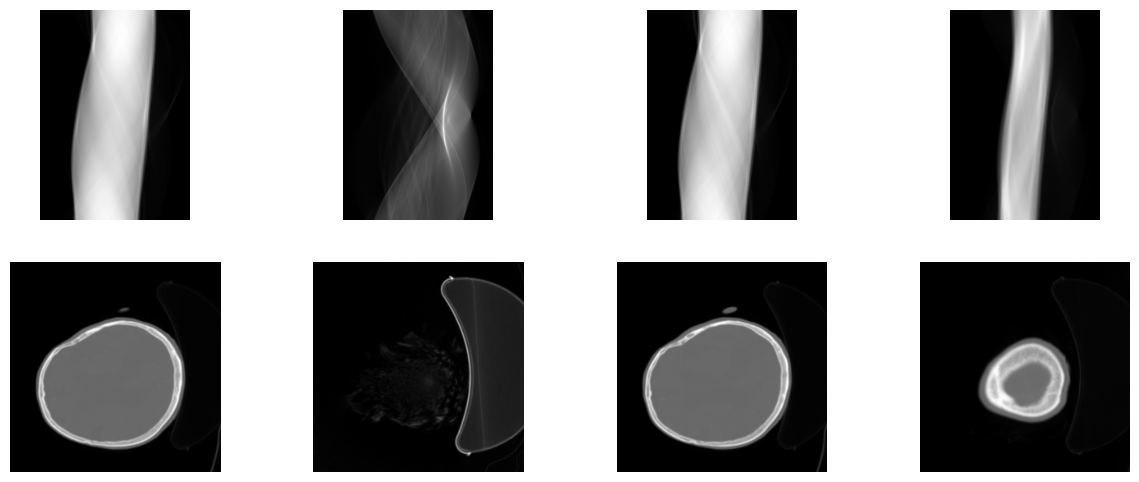

In [213]:
from matplotlib import pyplot as plt

def show_batch(loader):
    batch = next(iter(loader))
    sinograms, images = batch
    print("Sinograms shape:", sinograms.shape)
    print("Images shape:", images.shape)
    bs = sinograms.shape[0]
    for i in range(bs):
        plt.subplot(2, bs, i + 1)
        plt.imshow(sinograms[i], cmap="gray")
        plt.axis("off")
        plt.subplot(2, bs, i + 1 + bs)
        plt.imshow(images[i], cmap="gray")
        plt.axis("off")
        plt.gcf().set_size_inches(15, 6)
    plt.show()

show_batch(train_loader)

In [214]:
import numpy as np
import astra


def reconstruct_image_from_sinogram(sinogram, num_angles, img_size, algorithm="FBP"):
    """
    Rekonstruuje obraz z sinogramu.

    Parametry:
        sinogram (ndarray): Sinogram (2D array)
        num_angles (int): Liczba kątów projekcji
        img_size (int): Rozmiar obrazu (np. 256)
        algorithm (str): Algorytm rekonstrukcji (domyślnie "FBP")

    Zwraca:
        ndarray: zrekonstruowany obraz
    """
    # 1. Geometria projekcji (musi być taka sama jak przy tworzeniu sinogramu)
    angles = np.linspace(0, np.pi, num_angles, endpoint=False)
    proj_geom = astra.create_proj_geom("parallel", 1.0, sinogram.shape[1], angles)
    vol_geom = astra.create_vol_geom(img_size, img_size)

    # 2. Konfiguracja danych
    sinogram_id = astra.data2d.create("-sino", proj_geom, sinogram)

    # 3. Konfiguracja algorytmu FBP
    reco_id = astra.data2d.create("-vol", vol_geom)
    cfg = astra.astra_dict(algorithm)
    cfg["ReconstructionDataId"] = reco_id
    cfg["ProjectionDataId"] = sinogram_id
    cfg["ProjectorId"] = astra.create_projector("linear", proj_geom, vol_geom)

    alg_id = astra.algorithm.create(cfg)
    astra.algorithm.run(alg_id, iterations=200)

    # 4. Pobierz wynik
    reconstruction = astra.data2d.get(reco_id)

    # 5. Czyszczenie zasobów
    astra.algorithm.delete(alg_id)
    astra.data2d.delete(reco_id)
    astra.data2d.delete(sinogram_id)

    return reconstruction

In [215]:
# Get one sinogram, image pair from the data loader
batch = next(iter(train_loader))
sinograms, images = batch

index = 0  # Choose item in the batch
sinogram = sinograms[index].numpy()
image = images[index].numpy()

print("Sinogram shape:", sinogram.shape)
print("Image shape:", image.shape)

Sinogram shape: (512, 365)
Image shape: (256, 256)


In [216]:
reconstruction = reconstruct_image_from_sinogram(
    sinogram, num_angles=512, img_size=256, algorithm="FBP"
)

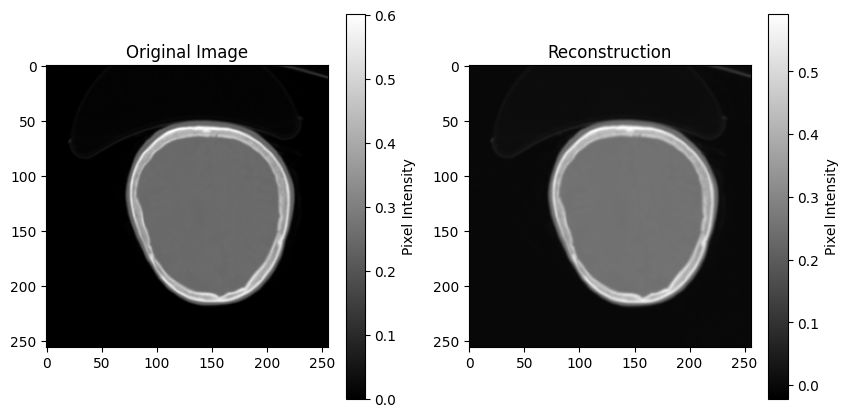

In [217]:
# Rotate image for correct orientation
image_rot = np.rot90(image)

# Rescale reconstruction to have the same min and max as the original image
# reconstruction = (reconstruction - reconstruction.min()) / (reconstruction.max() - reconstruction.min())
# reconstruction = reconstruction * (image_rot.max() - image_rot.min()) + image_rot.min()
reconstruction = reconstruction * 1000

# Display the original image and reconstruction
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image_rot, cmap="gray")
plt.colorbar(label='Pixel Intensity')

plt.subplot(1, 2, 2)
plt.title("Reconstruction")
plt.imshow(reconstruction, cmap="gray")
plt.colorbar(label='Pixel Intensity')

plt.gcf().set_size_inches(10, 5)
plt.show()

Maximum difference value: 0.134043


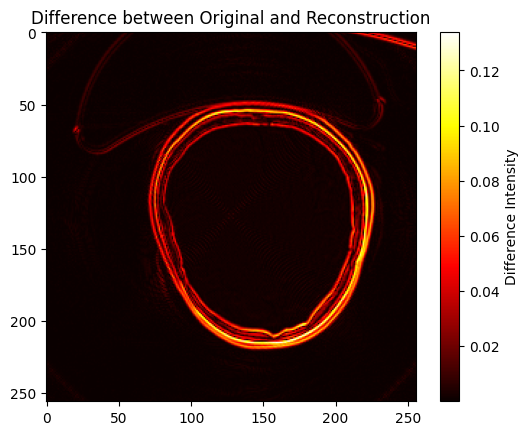

In [228]:
# Compare original and reconstruction pixel by pixel

difference = np.abs(image_rot.astype(np.float32) - reconstruction.astype(np.float32))

print("Maximum difference value:", np.max(difference))

plt.imshow(difference, cmap='hot')
plt.title("Difference between Original and Reconstruction")
plt.colorbar(label='Difference Intensity')
plt.show()

In [219]:
import math

def calculate_psnr(img1, img2, max_val=1.0):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(max_val) - 10 * math.log10(mse)

In [220]:
from skimage.metrics import structural_similarity as ssim

mse_diff = np.mean((image_rot - reconstruction) ** 2)
ssim_value = ssim(image_rot, reconstruction, data_range=image_rot.max() - image_rot.min())
psnr_value = calculate_psnr(image_rot, reconstruction, max_val=1.0)

print(f"MSE between original image and reconstruction: {mse_diff:.6f}")
print(f"SSIM between original image and reconstruction: {ssim_value:.4f}")
print(f"PSNR between original image and reconstruction: {psnr_value:.2f}")

MSE between original image and reconstruction: 0.000237
SSIM between original image and reconstruction: 0.9683
PSNR between original image and reconstruction: 36.25
